# Modelo Supervisado: Clasificación de Riesgo de Fraude

En este notebook entrenamos y evalúa un clasificador supervisado que predice si una transacción
tiene **bajo riesgo (0)** o **alto riesgo (1)** de fraude, usando como entrada las features
generadas en la etapa no supervisada (`features_no_supervisado.csv`).

## Introducción

En esta etapa se implementa un modelo de clasificación supervisada que utiliza las características generadas durante el aprendizaje no supervisado (anomalías de DBSCAN, log-probabilidades de GMM y clústeres asignados) para predecir el riesgo de fraude de una transacción. Su desempeño se evalúa mediante métricas como Precision, Recall, F1-Score y ROC-AUC. La clasificación y probabilidad de fraude obtenidas se utilizan posteriormente para decidir si una transacción debe aprobarse, revisarse o bloquearse.

## Fundamento teórico

### Regresión Logística

La **Regresión Logística** es un modelo de clasificación binaria que estima la probabilidad de que una transacción pertenezca a la clase positiva (fraude) mediante la función sigmoide:

$$
P(y=1|x)=\sigma(w^T x+b)=\frac{1}{1+e^{-(w^T x+b)}}
$$

### Justificación de la elección

La Regresión Logística fue seleccionada por tres razones principales:

* **Simplicidad del problema:** el conjunto de entrada contiene pocas variables, por lo que un modelo lineal resulta suficiente para capturar la relación con la variable objetivo.
* **Reducción del sobreajuste:** la proporción de fraudes es extremadamente baja (0.2%), lo que vuelve más propensos al sobreajuste a modelos complejos.
* **Interpretabilidad:** los coeficientes permiten explicar directamente la influencia de cada variable sobre la probabilidad de fraude, facilitando el análisis y la defensa de resultados.

### Manejo del desbalance de clases

El conjunto de datos presenta una relación aproximada de:

$$
499:1
$$

entre transacciones legítimas y fraudulentas. En estas condiciones, la métrica puede resultar engañosa, ya que un modelo que siempre prediga "no fraude" alcanzaría cerca del 99.8% de precisión global.

Para mitigar este problema se emplea:

```python
class_weight='balanced'
```

Esta estrategia incrementa la penalización asociada a errores sobre la clase minoritaria, favoreciendo una mejor detección de fraudes sin recurrir a técnicas de sobremuestreo sintético.


## Metodología

### Datos de entrada

Se utilizó el conjunto `features_no_supervisado.csv`, compuesto por 8,000 transacciones y las variables generadas en la fase no supervisada:

* `dbscan_anomalia`
* `gmm_logprob`
* `gmm_cluster`
* `Class` (variable objetivo)

La variable `idx_original` se excluyó del entrenamiento.

### Preprocesamiento

* `gmm_cluster` se transformó mediante **One-Hot Encoding**.
* `gmm_logprob` se normalizó con **StandardScaler**.
* Las variables binarias no requirieron transformación.

### Estrategia de validación

Se empleó **validación cruzada estratificada de 5 particiones (Stratified K-Fold)** para preservar la proporción de fraudes en cada división y obtener una evaluación más robusta.

### Modelo y evaluación

Se utilizó una **Regresión Logística** con `class_weight='balanced'`, `max_iter=1000` y `random_state=42`.

El desempeño se evaluó mediante predicciones *out-of-fold* utilizando las métricas:

* Accuracy
* Precision
* Recall
* F1-Score
* Matriz de confusión
* ROC-AUC


## Código

### Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

### Cargar y explorar los datos

In [2]:
df = pd.read_csv('data/processed/features_no_supervisado.csv')

print("Dimensiones:", df.shape)
print()
print("Distribución de la clase objetivo:")
print(df['Class'].value_counts())
print()
print("Proporción (%):")
print(df['Class'].value_counts(normalize=True) * 100)
df.head()

Dimensiones: (8000, 5)

Distribución de la clase objetivo:
Class
0    7984
1      16
Name: count, dtype: int64

Proporción (%):
Class
0    99.8
1     0.2
Name: proportion, dtype: float64


,idx_original,dbscan_anomalia,gmm_logprob,gmm_cluster,Class
0,231980,0,-2.749884,5,0
1,4673,0,-2.905640,4,0
2,106619,0,-8.424191,3,0
3,91344,0,-6.568957,6,0
4,21450,0,-2.030817,0,0


**Nota:** se confirma el fuerte desbalance: 7,984 transacciones legítimas (99.8%)
vs. 16 fraudes (0.2%). Esto se tendrá en cuenta en el modelo (`class_weight='balanced'`) y
en la elección de métricas (accuracy por sí sola no es suficiente).

### Preparar variables predictoras (X) y objetivo (y)

In [3]:
# idx_original se descarta: es solo un identificador, no aporta información predictiva
X = df[['dbscan_anomalia', 'gmm_logprob', 'gmm_cluster']].copy()
y = df['Class'].copy()

# gmm_cluster es categórica (0-6) -> one-hot encoding
X = pd.get_dummies(X, columns=['gmm_cluster'], prefix='cluster', drop_first=True)

print("Variables finales:", list(X.columns))
print("Shape de X:", X.shape)

Variables finales: ['dbscan_anomalia', 'gmm_logprob', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6']
Shape de X: (8000, 8)


In [4]:
# Escalar la variable continua (gmm_logprob). Las demás ya son binarias (0/1).
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled['gmm_logprob'] = scaler.fit_transform(X[['gmm_logprob']])

X_scaled.head()

,dbscan_anomalia,gmm_logprob,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6
0,0,0.243002,False,False,False,False,True,False
1,0,0.148003,False,False,False,True,False,False
2,0,-3.217881,False,False,True,False,False,False
3,0,-2.086333,False,False,False,False,False,True
4,0,0.681577,False,False,False,False,False,False


### Definir el modelo y la validación cruzada estratificada

In [5]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Stratified K-Fold: mantiene la proporción de fraude/no-fraude en cada fold.
# Crucial aquí porque solo hay 16 casos positivos en todo el dataset.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### Entrenar con validación cruzada y obtener predicciones *out-of-fold*

`cross_val_predict` entrena un modelo distinto en cada fold y devuelve, para cada observación,
la predicción hecha por el modelo que **no** la usó durante el entrenamiento. Esto da una
estimación más realista del desempeño que evaluar sobre los mismos datos de entrenamiento.

In [6]:
y_pred = cross_val_predict(model, X_scaled, y, cv=skf, method='predict')
y_proba = cross_val_predict(model, X_scaled, y, cv=skf, method='predict_proba')[:, 1]

### Calcular métricas

In [7]:
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred, zero_division=0)
rec = recall_score(y, y_pred, zero_division=0)
f1 = f1_score(y, y_pred, zero_division=0)
auc = roc_auc_score(y, y_proba)

print("Métricas (5-fold Cross-Validation estratificada)")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

Métricas (5-fold Cross-Validation estratificada)
Accuracy:  0.8588
Precision: 0.0097
Recall:    0.6875
F1-score:  0.0191
ROC-AUC:   0.8509


In [8]:
print(classification_report(y, y_pred, target_names=['No Fraude', 'Fraude'], zero_division=0))

              precision    recall  f1-score   support

   No Fraude       1.00      0.86      0.92      7984
      Fraude       0.01      0.69      0.02        16

    accuracy                           0.86      8000
   macro avg       0.50      0.77      0.47      8000
weighted avg       1.00      0.86      0.92      8000



### Matriz de confusión

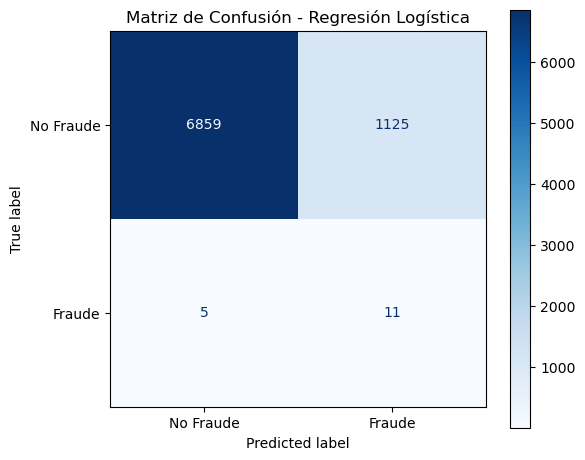

In [9]:
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraude', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.savefig('results/matriz_confusion.png', dpi=150)
plt.show()

### Curva ROC

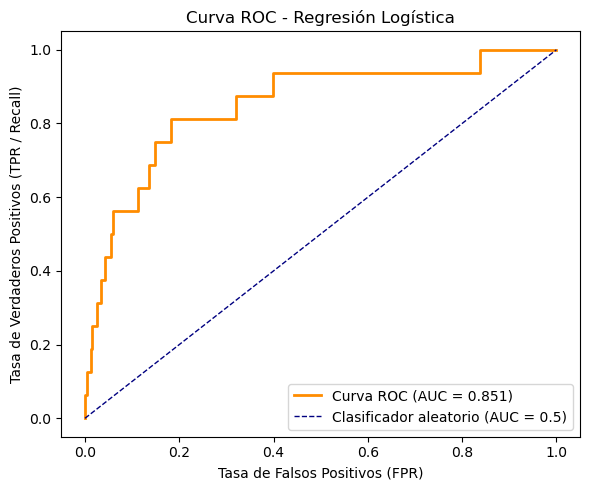

In [10]:
fpr, tpr, thresholds = roc_curve(y, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Clasificador aleatorio (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax.set_title('Curva ROC - Regresión Logística')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/roc_curve.png', dpi=150)
plt.show()

### Entrenar modelo final (con todos los datos) e interpretar coeficientes

In [11]:
# Una vez validado el desempeño, se entrena el modelo final con el 100% de los datos
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'variable': X_scaled.columns,
    'coeficiente': model.coef_[0]
}).sort_values('coeficiente')

print("Intercepto:", model.intercept_[0])
coef_df

Intercepto: -0.9408949812481732


,variable,coeficiente
0,dbscan_anomalia,-6.996473
6,cluster_5,-6.266661
3,cluster_2,-5.800405
7,cluster_6,-5.569201
1,gmm_logprob,-3.279243
2,cluster_1,-2.953474
4,cluster_3,-2.301578
5,cluster_4,0.305789


### Guardar métricas en CSV

In [12]:
metrics_df = pd.DataFrame([{
    'modelo': 'Regresion Logistica',
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1,
    'roc_auc': auc
}])
metrics_df.to_csv('metricas_supervisado.csv', index=False)
metrics_df

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Regresion Logistica,0.85875,0.009683,0.6875,0.019097,0.850936


## Resultados obtenidos

Con `class_weight='balanced'` y validación cruzada estratificada de 5 folds, se obtuvieron
los siguientes resultados sobre las predicciones *out-of-fold*:

| Métrica   | Valor |
|-----------|-------|
| Accuracy  | 0.8588 |
| Precision | 0.0097 |
| Recall    | 0.6875 |
| F1-score  | 0.0191 |
| ROC-AUC   | 0.8509 |

**Matriz de confusión:**

|                  | Predicho: No Fraude | Predicho: Fraude |
|------------------|---------------------|-------------------|
| **Real: No Fraude** | 6,859              | 1,125            |
| **Real: Fraude**    | 5                  | 11               |

El modelo detectó **11 de los 16 fraudes reales** (recall = 0.6875), a costa de generar
1,125 falsos positivos (precision = 0.0097). El ROC-AUC obtenido (0.8509) indica que el
modelo **sí separa razonablemente bien** ambas clases en términos de probabilidad, aunque
el punto de corte por defecto (0.5) no sea el ideal para esta aplicación.

## Interpretación de resultados

### Métricas relevantes

En detección de fraude, el **Recall** es especialmente importante porque mide la capacidad del modelo para identificar transacciones fraudulentas. Complementariamente, el **F1-Score** evalúa el equilibrio entre *Precision* y *Recall*, por lo que ambas métricas resultan más representativas que la *Accuracy* en conjuntos de datos desbalanceados.

### Análisis del desempeño

El modelo alcanza un **Recall ≈ 0.69**, identificando alrededor del 69% de los fraudes. Aunque la *Precision* es baja debido al incremento de falsos positivos, este comportamiento es esperado al utilizar `class_weight='balanced'`. Además, un **ROC-AUC ≈ 0.85** indica una buena capacidad para distinguir entre transacciones legítimas y fraudulentas.

La principal utilidad del modelo es generar una probabilidad de fraude que posteriormente será utilizada por el sistema de decisión.

### Limitaciones

* El conjunto contiene únicamente **16 casos de fraude**.
* Las variables provienen exclusivamente de la etapa no supervisada.
* La Regresión Logística prioriza interpretabilidad y robustez sobre la modelación de relaciones complejas.
